In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

# Data Preparation

In [2]:
# Loading the dataset
ratings= pd.read_csv(r'C:\Users\oluwa\Desktop\HNG INTERNSHIP\STAGE 1\ml-latest-small\ratings.csv')
movies = pd.read_csv(r'C:\Users\oluwa\Desktop\HNG INTERNSHIP\STAGE 1\ml-latest-small\movies.csv')
tags = pd.read_csv(r'C:\Users\oluwa\Desktop\HNG INTERNSHIP\STAGE 1\ml-latest-small\tags.csv')
links = pd.read_csv(r'C:\Users\oluwa\Desktop\HNG INTERNSHIP\STAGE 1\ml-latest-small\links.csv')

In [ ]:
# Merging rating and movie dataset using the inner merging type
df = ratings.merge(movies, how='inner', on= 'movieId')


In [ ]:
# Checking for duplicates and missing values
df.duplicated().sum()


In [ ]:
# Checking for missing values
df.isnull().sum()

In [ ]:
# Converting timestamp to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Feature Enginering

In [ ]:
# Extracting and creating a new column containing the release year of the movies
year = r'(\d{4})'

df['release_year']= df['title'].str.extract(year)
df['release_year']= pd.to_numeric(df['release_year']).astype('Int64')


In [ ]:
# Counting the number of genres for each movie and creating a new column for it
df['genre_count'] = df['genres'].str.count('\|') + 1
df.loc[df['genres'] == '(no genres listed)', 'genre_count'] = 0

print("Genre Count Value Distribution (Top 5):")
print(df['genre_count'].value_counts().sort_index().head()) 


In [ ]:
# Creating a new column containing the year the rating was given
df['rating_year']= df['timestamp'].dt.year


In [ ]:
# Creating a new column for the users average rating
df['user_avg_rating'] = df.groupby('userId')['rating'].transform('mean')


In [ ]:
# Creating a new column containing the total number of rating a movie has received
df['movie_rating_count'] = df.groupby('movieId')['rating'].transform('count')


In [ ]:
# Creating a new column calculating the amout of years since the movie was released till date of rating
df['movie_age_at_rating'] = df['rating_year'] - df['release_year']



# Exploratory Data Analysis

In [13]:

import matplotlib.pyplot as plt
import seaborn as sns


Overall Mean Rating is:
3.501556983616962


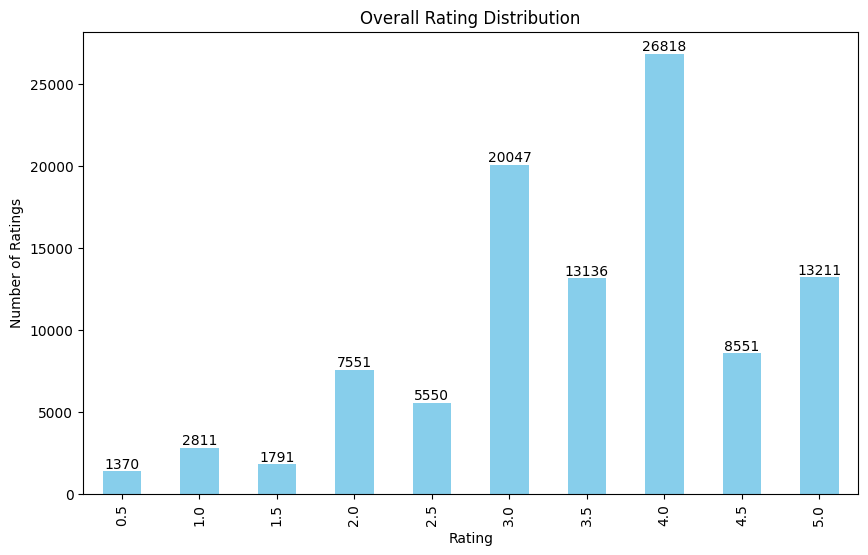

In [14]:
# Understanding the overall rating distribution across all movies (Do users tend to rate movies high, mid, or low?)

overall_rating = df['rating'].value_counts().sort_index()
overall_mean_rating = df['rating'].mean()

print(f"Overall Mean Rating is:\n{overall_mean_rating}")


# Visualizing the overall rating distribution
plt.figure(figsize=(10,6))
overall_rating.plot(kind='bar', color='skyblue')
plt.bar_label(plt.gca().containers[0])
plt.title('Overall Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()



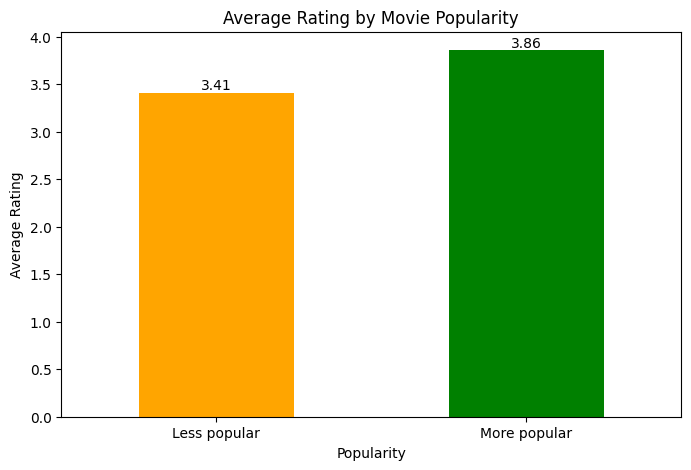

In [15]:
# Analyzing the impact of movie popularity on ratings (Do more popular movies(those with a higher rating count) receive higher average ratings?)
df['popularity'] = np.where(df['movie_rating_count'] < 100,'Less popular','More popular')
 
# Calculating average rating for low and high popularity movies    
popularity_rating = df.groupby('popularity')['rating'].mean()
popularity_rating

# Visualizing the average rating by movie popularity
plt.figure(figsize=(8,5))
popularity_rating.plot(kind='bar', color=['orange', 'green'])
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.title('Average Rating by Movie Popularity')
plt.xlabel('Popularity')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()


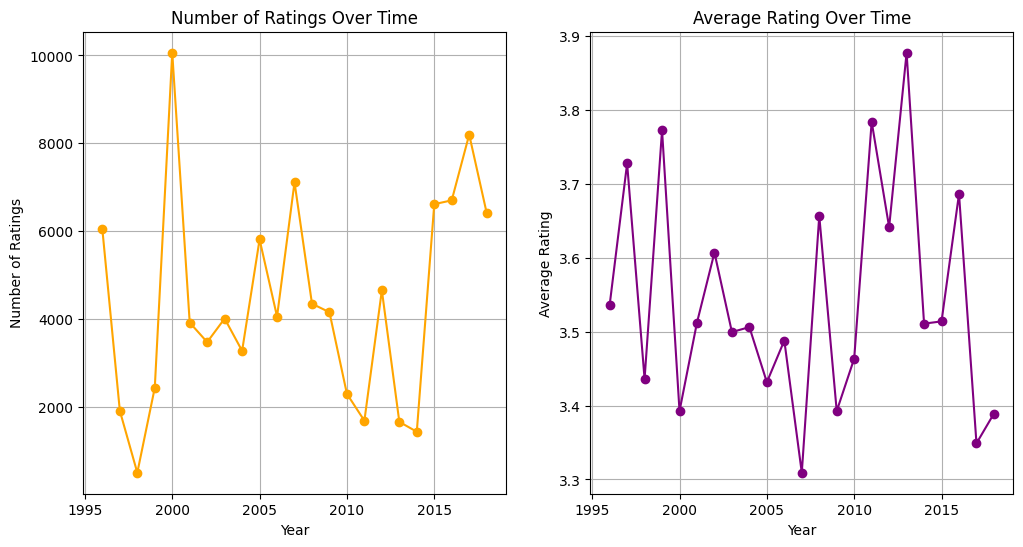

In [16]:
# Understanding the volume of rating and average rating over time (Do users tend to give higher or lower ratings as time progresses?)
df.groupby(df['rating_year']).agg({'rating': ['count', 'mean']})

# Plotting the number of ratings and average rating over time
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
ratings_count = df.groupby('rating_year')['rating'].count()
ratings_count.plot(marker='o', color='orange')
plt.title('Number of Ratings Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.grid()


plt.subplot(1, 2, 2)
ratings_over_time = df.groupby('rating_year')['rating'].mean()
ratings_over_time.plot(marker='o', color='purple')
plt.title('Average Rating Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid()

plt.show()


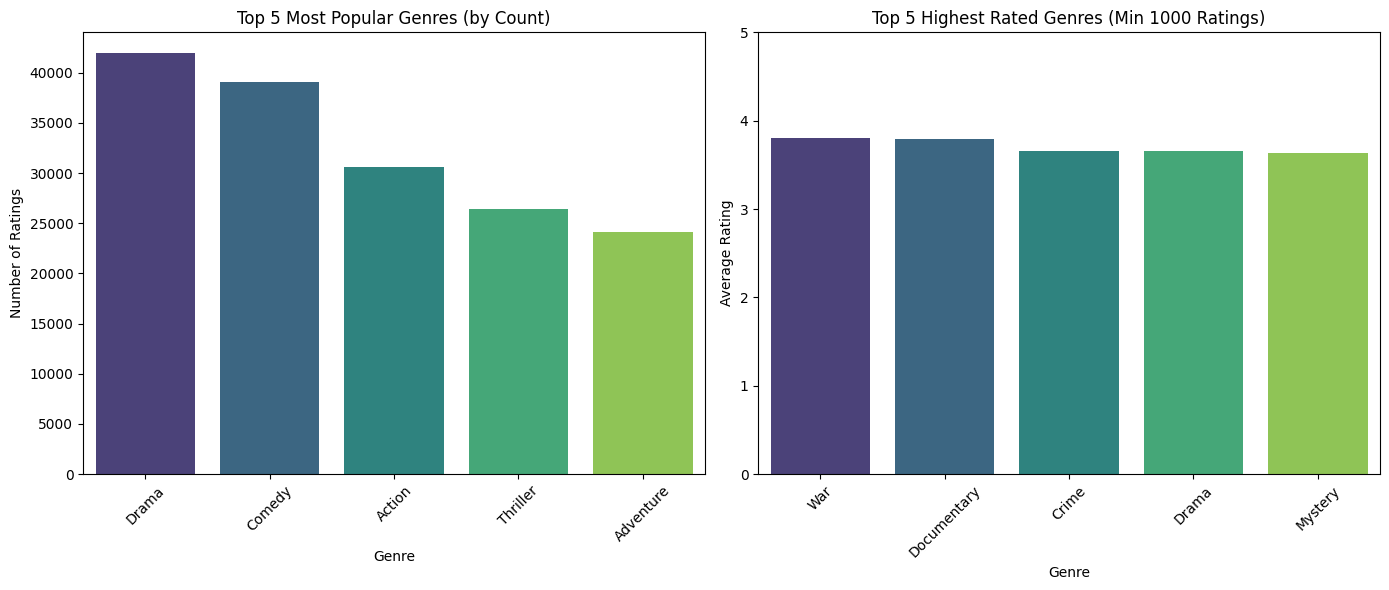

In [17]:
# Insight on the genre that gets the most ratings and the genre that gets the highest average ratings (Popularity and Quality perception)
df_genres = df['genres'].str.split('|', expand=True).stack().reset_index(level=1, drop=True).to_frame('genre')
df_new = df.merge(df_genres, left_index=True, right_index=True)
genre_popularity = df_new.groupby('genre').agg(rating_count =('rating','count'), average_rating = ('rating','mean')).reset_index()

# Finding the genre with the most ratings (Popularity)
top_genres_popularity = genre_popularity.sort_values(by='rating_count', ascending=False).head(5)

# Finding the genre with the most average rating (Quality perception)
min_ratings = 1000
top_genres_quality = genre_popularity[genre_popularity['rating_count'] >= min_ratings].sort_values(by='average_rating', ascending=False).head(5)

# Visualizing the results
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
sns.barplot(data=top_genres_popularity, x='genre', y='rating_count', palette='viridis')
plt.title('Top 5 Most Popular Genres (by Count)')
plt.xlabel('Genre')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)

# Visualizing the results
plt.subplot(1, 2, 2)
sns.barplot(data=top_genres_quality, x='genre', y='average_rating', palette='viridis')
plt.title('Top 5 Highest Rated Genres (Min 1000 Ratings)')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.ylim(0, 5)
plt.tight_layout()
plt.show()


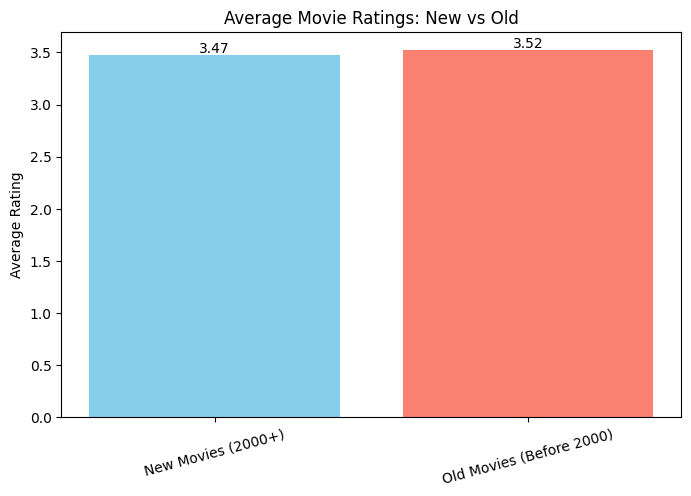

In [18]:
# Analysing the impact of movie age on ratings (Do older movies tend to receive higher or lower ratings compared to newer releases?)
new_movie = df[df['release_year'] >= 2000]['rating'].mean()

old_movie = df[df['release_year'] < 2000]['rating'].mean()

plt.figure(figsize=(8,5))
bars = plt.bar(['New Movies (2000+)','Old Movies (Before 2000)'], [new_movie, old_movie], color=['skyblue', 'salmon'])
plt.bar_label(bars, fmt='%.2f')
plt.title('Average Movie Ratings: New vs Old')
plt.ylabel('Average Rating')
plt.xticks(rotation=15)
plt.show()

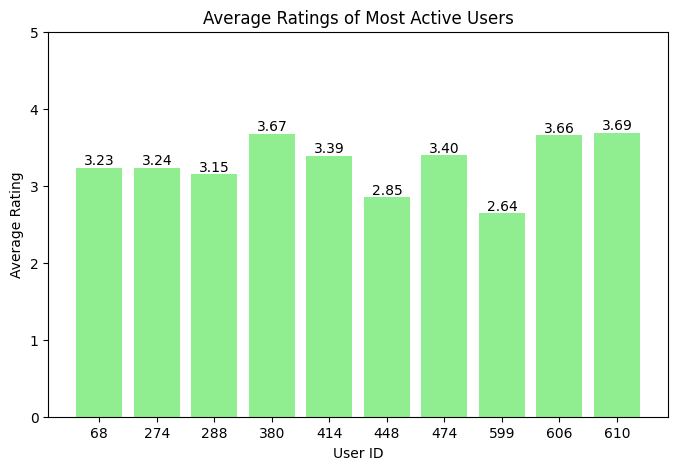

In [19]:
# Identifying the most active users and their rating behavior (Do the most active users tend to rate movies higher or lower than the average user?)
user_activity = df['userId'].value_counts().head(10).index
active_users = df[df['userId'].isin(user_activity)]
active_user_ratings = active_users.groupby('userId')['rating'].mean()
active_user_ratings

# Visualizing the average ratings of the most active users
plt.figure(figsize=(8,5))
bars = plt.bar(active_user_ratings.index.astype(str), active_user_ratings.values, color='lightgreen')
plt.title('Average Ratings of Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.bar_label(bars, fmt='%.2f')
plt.show()

In [ ]:
df.to_csv("cleaned_stage1.csv", index=False)